# Hierarchy-Aware Adaptive Chunking

This notebook implements a hierarchy-aware adaptive chunking pipeline for EMV specification documents.

The goal is to create chunks that keep the original document structure as much as possible while still respecting token limits for retrieval.  
The base unit is the section, but long sections are split using ordered block grouping. Tables are handled separately as atomic chunks because they often represent complete technical definitions on their own.


## 1. Imports

In this section, we import the standard Python libraries needed for:
- loading JSON data
- basic statistics
- plotting chunk size distributions
- working with paths

Only pure Python and common notebook libraries are used.


In [1]:
import json
import math
import statistics
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt


## 2. Load JSON data

The input file contains section-level objects for the processed EMV specification.

Each section includes:
- metadata such as title, level, parent relationship, and numbering
- ordered content blocks
- extracted tables

We load the file once and keep the full section list in memory for the chunking pipeline.


In [2]:
INPUT_PATH = "../../../data/processed/book4/done/final_chunk_ready.json"

input_path = Path(INPUT_PATH)
with input_path.open("r", encoding="utf-8") as f:
    sections = json.load(f)

print(f"Loaded {len(sections)} sections from: {input_path}")


Loaded 131 sections from: ../../../data/processed/book4/done/final_chunk_ready.json


## 3. Utility functions

Before chunking, it is useful to define helper functions for:
- cleaning and normalizing block content
- extracting text from a section
- checking whether a section is a leaf
- safely reading metadata from slightly different JSON schemas

The functions below are written to be practical and robust for project use.


In [3]:
def safe_get(data: Dict[str, Any], *keys: str, default=None):
    """Return the first existing key from a dictionary."""
    for key in keys:
        if key in data and data[key] is not None:
            return data[key]
    return default


def clean_text(text: Any) -> str:
    """Basic text cleanup used across blocks and tables."""
    if text is None:
        return ""
    text = str(text).replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines).strip()


def get_blocks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Return the list of blocks from a section, even if key names vary slightly."""
    return safe_get(section, "blocks", "content_blocks", default=[])


def get_tables(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Return the list of tables from a section."""
    return safe_get(section, "tables", default=[])


def get_page_num(section: Dict[str, Any]) -> Optional[int]:
    """Pick a representative page number for the section."""
    return safe_get(section, "page_num", "start_page", "page", default=None)


def get_parent_titles(section: Dict[str, Any]) -> List[str]:
    parent_titles = safe_get(section, "parent_titles", default=[])
    return parent_titles if isinstance(parent_titles, list) else []


def get_child_section_ids(section: Dict[str, Any]) -> List[str]:
    child_ids = safe_get(section, "child_section_ids", default=[])
    return child_ids if isinstance(child_ids, list) else []


def get_block_id(block: Dict[str, Any], fallback_index: int) -> str:
    """Use the existing block_id when available, otherwise create a stable fallback id."""
    return str(safe_get(block, "block_id", default=f"block_{fallback_index}"))


def section_metadata(section: Dict[str, Any]) -> Dict[str, Any]:
    """Extract the core metadata required for every chunk."""
    return {
        "section_id": safe_get(section, "section_id", default=""),
        "parent_section_id": safe_get(section, "parent_section_id", default=None),
        "child_section_ids": get_child_section_ids(section),
        "doc_id": safe_get(section, "doc_id", default=""),
        "title": safe_get(section, "title", default=""),
        "section_number": safe_get(section, "section_number", default=""),
        "page_num": get_page_num(section),
        "level": safe_get(section, "level", default=None),
        "parent_titles": get_parent_titles(section),
    }


## 4. Token estimation

For this project, token counting does not need an external tokenizer.

A lightweight approximation is enough for chunk boundary decisions:
- count words
- multiply by 1.3

This keeps the notebook simple and fully local.


In [4]:
def estimate_tokens(text: str) -> int:
    return int(len(text.split()) * 1.3)


## 5. Block normalization

The section content is made of blocks such as paragraphs and bullet lists.

To chunk correctly, we first convert every block into a clean text representation:
- paragraph -> use its text
- bullet_list -> join items with bullet formatting
- preserve intro_block_id if it exists, because it can be useful later for traceability


In [5]:
def normalize_block(block: Dict[str, Any], fallback_index: int = 0) -> Dict[str, Any]:
    """
    Convert one raw block into a normalized structure with clean text.

    Rules:
    - paragraph: use 'text'
    - bullet_list: join items with '\n- '
    - preserve intro_block_id when available
    """
    block_type = safe_get(block, "type", default="paragraph")
    intro_block_id = safe_get(block, "intro_block_id", default=None)
    block_id = get_block_id(block, fallback_index)

    text = ""
    if block_type == "paragraph":
        text = clean_text(safe_get(block, "text", default=""))
    elif block_type == "bullet_list":
        items = safe_get(block, "items", default=[])
        cleaned_items = [clean_text(item) for item in items if clean_text(item)]
        if cleaned_items:
            text = "- " + "\n- ".join(cleaned_items)
        else:
            text = ""
    else:
        raw_text = safe_get(block, "text", default="")
        if raw_text:
            text = clean_text(raw_text)
        else:
            items = safe_get(block, "items", default=[])
            cleaned_items = [clean_text(item) for item in items if clean_text(item)]
            text = "\n".join(cleaned_items).strip()

    return {
        "block_id": block_id,
        "intro_block_id": intro_block_id,
        "type": block_type,
        "text": text,
        "token_count": estimate_tokens(text) if text else 0,
    }


## 6. Section text extraction

This function rebuilds the textual body of a section by concatenating normalized blocks in order.

Important note:
- tables are ignored here because they are handled separately as atomic chunks


In [6]:
def get_section_text(section: Dict[str, Any]) -> str:
    normalized_blocks = [
        normalize_block(block, fallback_index=i)
        for i, block in enumerate(get_blocks(section), start=1)
    ]
    texts = [block["text"] for block in normalized_blocks if block["text"]]
    return "\n\n".join(texts).strip()


def is_leaf(section: Dict[str, Any]) -> bool:
    return len(get_child_section_ids(section)) == 0


## 7. Candidate chunk creation

Not every section should become a text chunk candidate.

The rules are:
- include all leaf sections
- include non-leaf sections only if they are substantial enough
- here, substantial enough means estimated text length is at least 80 tokens

This helps avoid creating noisy parent chunks that contain only headings or very small summaries.


In [7]:
# def merge_small_chunks(chunks, min_tokens=180, max_tokens=550):
#     """
#     Merge adjacent small text chunks when they belong to the same parent context.
#     Do not merge table chunks.
#     Prefer merging chunks from the same doc_id, parent_section_id, and type='text'.
#     """
#     merged = []
#     i = 0

#     while i < len(chunks):
#         current = chunks[i].copy()

#         if current.get("type") != "text" or current.get("token_count", 0) >= min_tokens:
#             merged.append(current)
#             i += 1
#             continue

#         group = [current]
#         total_tokens = current.get("token_count", 0)
#         j = i + 1

#         while j < len(chunks):
#             nxt = chunks[j]

#             if nxt.get("type") != "text":
#                 break

#             same_doc = nxt.get("doc_id") == current.get("doc_id")
#             same_parent = nxt.get("parent_section_id") == current.get("parent_section_id")
#             same_level = nxt.get("level") == current.get("level")

#             if not (same_doc and same_parent and same_level):
#                 break

#             nxt_tokens = nxt.get("token_count", 0)
#             if total_tokens + nxt_tokens > max_tokens:
#                 break

#             group.append(nxt)
#             total_tokens += nxt_tokens

#             if total_tokens >= min_tokens:
#                 break

#             j += 1

#         if len(group) == 1:
#             merged.append(current)
#             i += 1
#             continue

#         merged_text = "\n\n".join(c.get("text", "").strip() for c in group if c.get("text"))
#         merged_block_ids = []
#         merged_parent_titles = group[0].get("parent_titles", [])

#         for c in group:
#             merged_block_ids.extend(c.get("source_block_ids", []))

#         first = group[0]
#         last = group[-1]

#         merged_chunk = {
#             **first,
#             "chunk_id": f"{first['chunk_id']}__merged__{last['chunk_id']}",
#             "section_id": first.get("section_id"),
#             "chunk_index": f"merged_{len(group)}",
#             "title": first.get("title"),
#             "text": merged_text,
#             "token_count": total_tokens,
#             "source_block_ids": merged_block_ids,
#             "block_count": len(merged_block_ids),
#             "parent_titles": merged_parent_titles,
#             "is_split": False,
#             "split_group_id": None,
#             "candidate_source": "merged_small_chunks",
#             "chunking_reason": "merged_below_180",
#             "size_band": (
#                 "below_180" if total_tokens < 180
#                 else "between_180_349" if total_tokens < 350
#                 else "between_350_550" if total_tokens <= 550
#                 else "above_550"
#             ),
#             "merged_from_chunk_ids": [c["chunk_id"] for c in group],
#             "merged_from_section_ids": [c["section_id"] for c in group],
#         }

#         merged.append(merged_chunk)
#         i += len(group)

#     return merged

In [8]:
MIN_PARENT_TOKENS = 80
PREFERRED_MIN = 350
PREFERRED_MAX = 550
SMALL_MIN = 180
OVERLAP_MIN = 30
OVERLAP_MAX = 50
DEFAULT_OVERLAP_TARGET = 40


def classify_size_band(token_count: int) -> str:
    if token_count < SMALL_MIN:
        return "below_180"
    if token_count < PREFERRED_MIN:
        return "between_180_349"
    if token_count <= PREFERRED_MAX:
        return "between_350_550"
    return "above_550"


def create_candidate(section: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    text = get_section_text(section)
    token_count = estimate_tokens(text)

    leaf = is_leaf(section)
    include = leaf or (token_count >= MIN_PARENT_TOKENS)

    if not include or not text:
        return None

    metadata = section_metadata(section)
    candidate_source = "leaf" if leaf else "non_leaf_large"

    return {
        **metadata,
        "text": text,
        "token_count": token_count,
        "is_leaf": leaf,
        "candidate_source": candidate_source,
        "size_band": classify_size_band(token_count),
    }


## 8. Chunking logic

The chunking strategy is adaptive:
- keep a section as one chunk when it already fits
- split only when it exceeds the maximum size
- splitting is done by grouping full blocks in order
- no block is split internally

An overlap of about 30 to 50 tokens is added only between split chunks.  
This overlap is created using the tail of the previous chunk and helps retrieval preserve context across chunk boundaries.


In [9]:
def build_overlap_text(previous_text: str, target_tokens: int = DEFAULT_OVERLAP_TARGET) -> str:
    """Return a short overlap tail from the previous chunk."""
    words = previous_text.split()
    if not words:
        return ""

    overlap_word_count = max(1, math.ceil(target_tokens / 1.3))
    overlap_words = words[-overlap_word_count:]
    overlap_text = " ".join(overlap_words).strip()

    overlap_tokens = estimate_tokens(overlap_text)
    if overlap_tokens < OVERLAP_MIN:
        extra_words = max(1, math.ceil((OVERLAP_MIN - overlap_tokens) / 1.3))
        overlap_words = words[-(overlap_word_count + extra_words):]
        overlap_text = " ".join(overlap_words).strip()
    elif overlap_tokens > OVERLAP_MAX:
        while overlap_text and estimate_tokens(overlap_text) > OVERLAP_MAX:
            overlap_words = overlap_words[1:]
            overlap_text = " ".join(overlap_words).strip()

    return overlap_text


def detect_oversize_reason(chunk_type: str, token_count: int, block_count: int) -> Optional[str]:
    """Explain why a chunk still exceeds the threshold."""
    if token_count <= PREFERRED_MAX:
        return None
    if chunk_type == "table":
        return "table_atomic"
    if block_count <= 1:
        return "single_block_atomic"
    return "sequential_grouping_limit"


def make_text_chunk(
    section: Dict[str, Any],
    chunk_text: str,
    chunk_index: int,
    total_chunks: int,
    source_block_ids: Optional[List[str]] = None,
    block_count: int = 0,
    is_split: bool = False,
    overlap_prev_tokens: int = 0,
    overlap_next_tokens: int = 0,
    candidate_source: str = "leaf",
    chunking_reason: str = "kept_in_range",
) -> Dict[str, Any]:
    metadata = section_metadata(section)
    section_id = metadata["section_id"]
    final_text = chunk_text.strip()
    token_count = estimate_tokens(final_text)

    return {
        "chunk_id": f"{section_id}_text_{chunk_index}",
        "section_id": section_id,
        "chunk_index": f"{chunk_index}/{total_chunks}",
        "doc_id": metadata["doc_id"],
        "title": metadata["title"],
        "section_number": metadata["section_number"],
        "page_num": metadata["page_num"],
        "level": metadata["level"],
        "parent_titles": metadata["parent_titles"],
        "parent_section_id": metadata["parent_section_id"],
        "child_section_ids": metadata["child_section_ids"],
        "text": final_text,
        "token_count": token_count,
        "type": "text",
        "source_block_ids": source_block_ids or [],
        "block_count": block_count,
        "is_split": is_split,
        "split_group_id": section_id if is_split else None,
        "overlap_prev_tokens": overlap_prev_tokens,
        "overlap_next_tokens": overlap_next_tokens,
        "candidate_source": candidate_source,
        "chunking_reason": chunking_reason,
        "size_band": classify_size_band(token_count),
        "oversize_reason": detect_oversize_reason("text", token_count, block_count),
    }


def split_section_into_chunks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Split a section into multiple text chunks by grouping blocks sequentially.

    Rules:
    - do not break inside paragraphs
    - do not break inside bullet lists
    - stop before exceeding 550 tokens
    - add 30-50 token overlap only between split chunks
    """
    normalized_blocks = [
        normalize_block(block, fallback_index=i)
        for i, block in enumerate(get_blocks(section), start=1)
    ]
    normalized_blocks = [block for block in normalized_blocks if block["text"]]

    if not normalized_blocks:
        return []

    groups: List[List[Dict[str, Any]]] = []
    current_group: List[Dict[str, Any]] = []
    current_texts: List[str] = []

    for block in normalized_blocks:
        candidate_texts = current_texts + [block["text"]]
        candidate_text = "\n\n".join(candidate_texts).strip()
        candidate_tokens = estimate_tokens(candidate_text)

        if current_group and candidate_tokens > PREFERRED_MAX:
            groups.append(current_group)
            current_group = [block]
            current_texts = [block["text"]]
        else:
            current_group.append(block)
            current_texts.append(block["text"])

    if current_group:
        groups.append(current_group)

    chunks: List[Dict[str, Any]] = []
    base_texts = [
        "\n\n".join(block["text"] for block in group if block["text"]).strip()
        for group in groups
    ]

    total_chunks = len(groups)
    candidate_source = "leaf" if is_leaf(section) else "non_leaf_large"

    for idx, group in enumerate(groups, start=1):
        base_text = base_texts[idx - 1]
        overlap_text = ""
        overlap_prev_tokens = 0

        if idx > 1:
            overlap_text = build_overlap_text(base_texts[idx - 2], DEFAULT_OVERLAP_TARGET)
            overlap_prev_tokens = estimate_tokens(overlap_text) if overlap_text else 0

        final_text = f"{overlap_text}\n\n{base_text}".strip() if overlap_text else base_text

        overlap_next_tokens = 0
        if idx < total_chunks:
            preview_overlap = build_overlap_text(base_text, DEFAULT_OVERLAP_TARGET)
            overlap_next_tokens = estimate_tokens(preview_overlap) if preview_overlap else 0

        source_block_ids = [block["block_id"] for block in group if block.get("block_id")]

        chunk = make_text_chunk(
            section=section,
            chunk_text=final_text,
            chunk_index=idx,
            total_chunks=total_chunks,
            source_block_ids=source_block_ids,
            block_count=len(group),
            is_split=True,
            overlap_prev_tokens=overlap_prev_tokens,
            overlap_next_tokens=overlap_next_tokens,
            candidate_source=candidate_source,
            chunking_reason="split_over_550",
        )
        chunks.append(chunk)

    return chunks


## 9. Table handling

Tables are stored as separate atomic chunks.

This is important in EMV specifications because many tables contain definitions, command fields, constraints, or mappings that should not be split across chunks.


In [10]:
def table_to_text(table: Dict[str, Any]) -> str:
    """Convert a table object into a readable text form."""
    title = clean_text(safe_get(table, "title", "caption", default=""))
    headers = safe_get(table, "headers", default=[])
    rows = safe_get(table, "rows", default=[])

    parts = []

    if title:
        parts.append(f"Table: {title}")

    if headers:
        header_line = " | ".join(clean_text(h) for h in headers if clean_text(h))
        if header_line:
            parts.append(header_line)

    for row in rows:
        if isinstance(row, list):
            row_text = " | ".join(clean_text(cell) for cell in row)
        else:
            row_text = clean_text(row)
        if row_text:
            parts.append(row_text)

    if not parts:
        raw_text = clean_text(safe_get(table, "text", default=""))
        if raw_text:
            parts.append(raw_text)

    return "\n".join(parts).strip()


def build_table_chunks(section: Dict[str, Any]) -> List[Dict[str, Any]]:
    metadata = section_metadata(section)
    section_id = metadata["section_id"]
    tables = get_tables(section)
    table_chunks = []

    for idx, table in enumerate(tables, start=1):
        table_text = table_to_text(table)
        if not table_text:
            continue

        token_count = estimate_tokens(table_text)
        rows = safe_get(table, "rows", default=[])
        table_id = safe_get(table, "table_id", default=f"{section_id}_table_{idx}")
        table_title = clean_text(safe_get(table, "title", "caption", default=""))

        table_chunks.append({
            "chunk_id": f"{section_id}_table_{idx}",
            "section_id": section_id,
            "chunk_index": f"{idx}/{len(tables)}",
            "doc_id": metadata["doc_id"],
            "title": metadata["title"],
            "section_number": metadata["section_number"],
            "page_num": metadata["page_num"],
            "level": metadata["level"],
            "parent_titles": metadata["parent_titles"],
            "parent_section_id": metadata["parent_section_id"],
            "child_section_ids": metadata["child_section_ids"],
            "text": table_text,
            "token_count": token_count,
            "type": "table",
            "source_block_ids": [],
            "block_count": 1,
            "is_split": False,
            "split_group_id": None,
            "overlap_prev_tokens": 0,
            "overlap_next_tokens": 0,
            "candidate_source": "table",
            "chunking_reason": "table_atomic",
            "size_band": classify_size_band(token_count),
            "oversize_reason": detect_oversize_reason("table", token_count, 1),
            "table_id": table_id,
            "table_title": table_title if table_title else None,
            "table_row_count": len(rows) if isinstance(rows, list) else None,
        })

    return table_chunks


## 10. Final pipeline

Now we combine everything into one pipeline:
1. iterate over sections
2. create text candidates
3. keep sections as-is or split them when needed
4. add table chunks
5. return the final chunk list

This produces a clean chunk set ready for embedding and retrieval.


In [11]:
def build_chunks(sections: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    final_chunks: List[Dict[str, Any]] = []

    for section in sections:
        candidate = create_candidate(section)

        if candidate is not None:
            if candidate["token_count"] > PREFERRED_MAX:
                split_chunks = split_section_into_chunks(section)
                final_chunks.extend(split_chunks)
            else:
                final_chunks.append(
                    make_text_chunk(
                        section=section,
                        chunk_text=candidate["text"],
                        chunk_index=1,
                        total_chunks=1,
                        source_block_ids=[
                            normalize_block(block, fallback_index=i)["block_id"]
                            for i, block in enumerate(get_blocks(section), start=1)
                            if normalize_block(block, fallback_index=i)["text"]
                        ],
                        block_count=sum(
                            1
                            for i, block in enumerate(get_blocks(section), start=1)
                            if normalize_block(block, fallback_index=i)["text"]
                        ),
                        is_split=False,
                        overlap_prev_tokens=0,
                        overlap_next_tokens=0,
                        candidate_source=candidate["candidate_source"],
                        chunking_reason="kept_in_range",
                    )
                )

        table_chunks = build_table_chunks(section)
        final_chunks.extend(table_chunks)
#--------------------------------------------------------------
        # final_chunks = sorted(
        #     final_chunks,
        #     key=lambda x: (
        #         x.get("doc_id", ""),
        #         x.get("page_num", 0),
        #         x.get("level", 0),
        #         x.get("section_number", ""),
        #         x.get("chunk_id", "")
        #     )
        # )
        
        # final_chunks = merge_small_chunks(final_chunks, min_tokens=180, max_tokens=550)
#-------------------------------------------------------------------
    return final_chunks


## 11. Execution pipeline

This cell runs the complete chunking process on the loaded EMV Book 4 data.


In [12]:
chunks = build_chunks(sections)

print(f"Total chunks created: {len(chunks)}")
print(f"Text chunks: {sum(1 for c in chunks if c['type'] == 'text')}")
print(f"Table chunks: {sum(1 for c in chunks if c['type'] == 'table')}")


Total chunks created: 160
Text chunks: 102
Table chunks: 58


## 12. Results analysis

To evaluate the chunking strategy, we calculate:
- total number of chunks
- average chunk size
- number of split sections
- number of table chunks
- distribution of chunk token counts

This helps verify whether the chosen thresholds are producing a useful chunk set.


In [13]:
def summarize_chunks(chunks: List[Dict[str, Any]]) -> Dict[str, Any]:
    token_counts = [chunk["token_count"] for chunk in chunks]
    text_chunks = [chunk for chunk in chunks if chunk["type"] == "text"]
    table_chunks = [chunk for chunk in chunks if chunk["type"] == "table"]

    section_chunk_counts = {}
    for chunk in text_chunks:
        section_chunk_counts.setdefault(chunk["section_id"], 0)
        section_chunk_counts[chunk["section_id"]] += 1

    split_sections = {section_id: count for section_id, count in section_chunk_counts.items() if count > 1}

    size_band_counts = {
        "below_180": 0,
        "between_180_349": 0,
        "between_350_550": 0,
        "above_550": 0,
    }
    for chunk in chunks:
        size_band_counts[chunk["size_band"]] += 1

    oversize_chunks = [chunk for chunk in chunks if chunk["token_count"] > PREFERRED_MAX]
    oversize_reason_counts = {}
    for chunk in oversize_chunks:
        reason = chunk.get("oversize_reason") or "unknown"
        oversize_reason_counts[reason] = oversize_reason_counts.get(reason, 0) + 1

    return {
        "num_chunks": len(chunks),
        "num_text_chunks": len(text_chunks),
        "num_table_chunks": len(table_chunks),
        "avg_tokens": round(statistics.mean(token_counts), 2) if token_counts else 0,
        "median_tokens": round(statistics.median(token_counts), 2) if token_counts else 0,
        "min_tokens": min(token_counts) if token_counts else 0,
        "max_tokens": max(token_counts) if token_counts else 0,
        "num_splits": len(split_sections),
        "split_sections": split_sections,
        "size_band_counts": size_band_counts,
        "num_oversize_chunks": len(oversize_chunks),
        "oversize_reason_counts": oversize_reason_counts,
    }


summary = summarize_chunks(chunks)
summary


{'num_chunks': 160,
 'num_text_chunks': 102,
 'num_table_chunks': 58,
 'avg_tokens': 182.59,
 'median_tokens': 114.5,
 'min_tokens': 6,
 'max_tokens': 590,
 'num_splits': 8,
 'split_sections': {'EMV_Book_2_v4.4_15_PartI.2': 2,
  'EMV_Book_2_v4.4_18_PartI.3': 5,
  'EMV_Book_2_v4.4_26_PartI.4.1': 3,
  'EMV_Book_2_v4.4_33_PartI.4.2': 2,
  'EMV_Book_2_v4.4_45_PartII.6.3.2.2': 3,
  'EMV_Book_2_v4.4_85_PartIV.11.1': 2,
  'EMV_Book_2_v4.4_90_PartIV.12.1': 2,
  'EMV_Book_2_v4.4_130_PartV.E3': 3},
 'size_band_counts': {'below_180': 94,
  'between_180_349': 28,
  'between_350_550': 33,
  'above_550': 5},
 'num_oversize_chunks': 5,
 'oversize_reason_counts': {'sequential_grouping_limit': 5}}

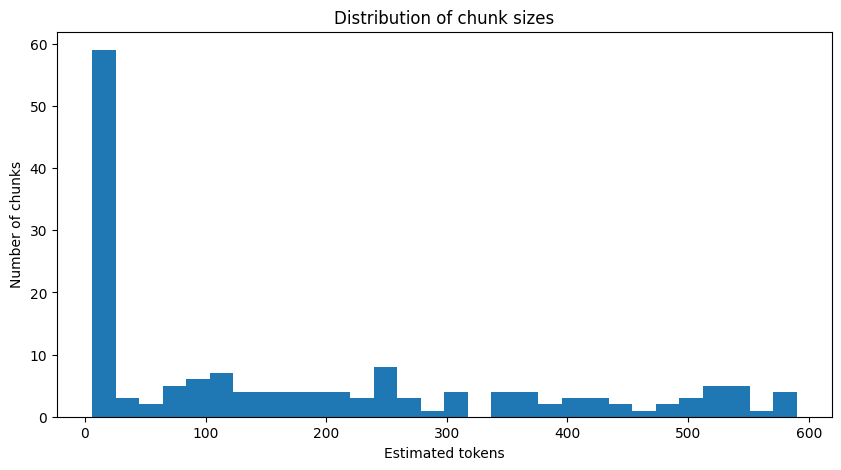

In [14]:
plt.figure(figsize=(10, 5))
plt.hist([chunk["token_count"] for chunk in chunks], bins=30)
plt.xlabel("Estimated tokens")
plt.ylabel("Number of chunks")
plt.title("Distribution of chunk sizes")
plt.show()


## 13. Threshold quality check

This quick check shows how many chunks fall into the main size bands:
- below 180 tokens
- between 180 and 349
- between 350 and 550
- above 550

The ideal outcome is that most text chunks remain in the preferred range or near it, while still preserving structure.


In [15]:
def count_by_size_band(chunks: List[Dict[str, Any]]) -> Dict[str, int]:
    counts = {
        "below_180": 0,
        "between_180_349": 0,
        "between_350_550": 0,
        "above_550": 0,
    }

    for chunk in chunks:
        counts[chunk["size_band"]] += 1

    return counts


band_counts = count_by_size_band(chunks)
band_counts


{'below_180': 94, 'between_180_349': 28, 'between_350_550': 33, 'above_550': 5}

## 14. Sample outputs

Finally, we inspect a few examples:
- 3 normal chunks
- 1 split example
- 1 table chunk

This makes it easier to manually verify whether the chunking logic is preserving the original section meaning.


In [16]:
def print_chunk_preview(chunk: Dict[str, Any], max_chars: int = 700):
    print("=" * 100)
    print(f"chunk_id         : {chunk['chunk_id']}")
    print(f"type             : {chunk['type']}")
    print(f"section_id       : {chunk['section_id']}")
    print(f"chunk_index      : {chunk['chunk_index']}")
    print(f"title            : {chunk['title']}")
    print(f"section_no       : {chunk['section_number']}")
    print(f"page_num         : {chunk['page_num']}")
    print(f"level            : {chunk['level']}")
    print(f"token_count      : {chunk['token_count']}")
    print(f"is_split         : {chunk.get('is_split')}")
    print(f"candidate_source : {chunk.get('candidate_source')}")
    print(f"chunking_reason  : {chunk.get('chunking_reason')}")
    print(f"source_block_ids : {chunk.get('source_block_ids')}")
    print(f"oversize_reason  : {chunk.get('oversize_reason')}")
    if chunk["type"] == "table":
        print(f"table_id         : {chunk.get('table_id')}")
        print(f"table_title      : {chunk.get('table_title')}")
        print(f"table_row_count  : {chunk.get('table_row_count')}")
    print("-" * 100)
    preview = chunk["text"][:max_chars]
    print(preview + ("..." if len(chunk["text"]) > max_chars else ""))
    print()


normal_chunks = [c for c in chunks if c["type"] == "text" and c["chunk_index"] == "1/1"][:3]

for chunk in normal_chunks:
    print_chunk_preview(chunk)


chunk_id         : EMV_Book_2_v4.4_12_PartI.1_text_1
type             : text
section_id       : EMV_Book_2_v4.4_12_PartI.1
chunk_index      : 1/1
title            : Scope
section_no       : PartI.1
page_num         : 12
level            : 1
token_count      : 109
is_split         : False
candidate_source : non_leaf_large
chunking_reason  : kept_in_range
source_block_ids : ['PartI.1_b1', 'PartI.1_b2']
oversize_reason  : None
----------------------------------------------------------------------------------------------------
This document, the Integrated Circuit Card Specifications for Payment SystemsBook 4, Cardholder, Attendant, and Acquirer Interface Requirements for Payment Systems , defines the mandatory, recommended, and optional terminal requirements necessary to support the acceptance of integrated circuit cards (ICCs) in accordance with the other documents of the Integrated Circuit Card Specifications for Payment Systems , all available on http://www.emvco.com:

- Book 1 – Appli

In [17]:
split_example = None
for section_id, count in summary["split_sections"].items():
    if count > 1:
        related = [c for c in chunks if c["section_id"] == section_id and c["type"] == "text"]
        split_example = related
        break

if split_example:
    for chunk in split_example:
        print_chunk_preview(chunk)
else:
    print("No split example found in this dataset.")


chunk_id         : EMV_Book_2_v4.4_15_PartI.2_text_1
type             : text
section_id       : EMV_Book_2_v4.4_15_PartI.2
chunk_index      : 1/2
title            : Normative References
section_no       : PartI.2
page_num         : 15
level            : 1
token_count      : 546
is_split         : True
candidate_source : leaf
chunking_reason  : split_over_550
source_block_ids : ['PartI.2_b1', 'PartI.2_b2', 'PartI.2_b3', 'PartI.2_b4', 'PartI.2_b5', 'PartI.2_b6', 'PartI.2_b7', 'PartI.2_b8', 'PartI.2_b9', 'PartI.2_b10', 'PartI.2_b11', 'PartI.2_b12', 'PartI.2_b13', 'PartI.2_b14', 'PartI.2_b15', 'PartI.2_b16', 'PartI.2_b17', 'PartI.2_b18', 'PartI.2_b19', 'PartI.2_b20', 'PartI.2_b21', 'PartI.2_b22', 'PartI.2_b23', 'PartI.2_b24', 'PartI.2_b25', 'PartI.2_b26', 'PartI.2_b27', 'PartI.2_b28', 'PartI.2_b29', 'PartI.2_b30', 'PartI.2_b31', 'PartI.2_b32', 'PartI.2_b33', 'PartI.2_b34', 'PartI.2_b35', 'PartI.2_b36', 'PartI.2_b37', 'PartI.2_b38', 'PartI.2_b39', 'PartI.2_b40', 'PartI.2_b41', 'PartI.2_b42'

In [18]:
table_example = next((c for c in chunks if c["type"] == "table"), None)

if table_example:
    print_chunk_preview(table_example, max_chars=700)
else:
    print("No table chunk found in this dataset.")


chunk_id         : EMV_Book_2_v4.4_38_PartII.5.1_table_1
type             : table
section_id       : EMV_Book_2_v4.4_38_PartII.5.1
chunk_index      : 1/1
title            : Terminal Types
section_no       : PartII.5.1
page_num         : 38
level            : 2
token_count      : 9
is_split         : False
candidate_source : table
chunking_reason  : table_atomic
source_block_ids : []
oversize_reason  : None
table_id         : p0038_t01
table_title      : Table 1: Terms Describing Terminal Types
table_row_count  : 0
----------------------------------------------------------------------------------------------------
Table: Table 1: Terms Describing Terminal Types



## 15. Optional export

If needed, the final chunks can be saved as a JSON file for the embedding stage.

The exported records now include a bit more traceability metadata:
- `parent_section_id` and `child_section_ids`
- `source_block_ids` and `block_count`
- split indicators and overlap metadata
- chunking reason and oversize reason
- table-specific identifiers


In [19]:
OUTPUT_PATH = input_path.parent / "adaptive_chunks_with_metadata.json"

with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    json.dump(chunks, f, ensure_ascii=False, indent=2)

print(f"Saved chunked output to: {OUTPUT_PATH}")


Saved chunked output to: ../../../data/processed/book4/done/adaptive_chunks_with_metadata.json
